In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('housing.csv')

In [4]:
# firstly we will perform basic eda before moving towards feature selection 
df.shape

(20640, 10)

In [5]:
# we can see there are 20.64 k rows 
df.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6333,-117.95,33.99,25.0,1075.0,138.0,451.0,132.0,6.8492,332200.0,<1H OCEAN
3335,-122.64,38.87,16.0,1177.0,240.0,519.0,199.0,1.5739,73500.0,INLAND
14113,-117.11,32.74,25.0,684.0,190.0,665.0,187.0,2.4524,90300.0,NEAR OCEAN
10055,-121.03,39.26,49.0,3739.0,759.0,1422.0,606.0,2.4283,143100.0,INLAND
13669,-117.25,34.08,30.0,2981.0,605.0,1784.0,573.0,2.4500,85800.0,INLAND


In [6]:
# now we will do train test split of the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:8],df['median_house_value'],test_size=0.3,random_state=0)

In [8]:
# now we will scale the input values as per need 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
# converting into a dataframe
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [11]:
x_train_scaled

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-0.111314,0.513964,1.856210,-1.153589,-1.204687,-1.071870,-1.199496,-1.000304
1,-1.317384,0.999935,1.141712,-0.740637,-0.496410,-0.512516,-0.580834,-0.849386
2,0.760844,-0.822456,-0.922393,-0.128737,-0.335867,-0.033194,-0.353731,1.286205
3,0.641234,-0.733673,-0.922393,-0.055729,1.552873,1.414342,1.306475,-1.135200
4,-0.121281,0.513964,1.697432,-0.852431,-0.812774,-0.712596,-0.867977,-0.870432
...,...,...,...,...,...,...,...,...
14443,-0.843927,1.233574,-0.684227,-0.605115,-0.730141,-0.620385,-0.732237,0.288633
14444,-0.659528,0.864424,-0.128507,-0.694550,-0.810413,-0.676929,-0.758340,-0.504030
14445,-1.162887,0.443872,0.189048,-0.551728,NaN,-0.627344,-0.278029,-0.353747
14446,0.815665,-0.939276,0.427214,-0.235055,-0.095053,-0.324614,-0.082250,0.933234


In [12]:
# now you can see we scaled down the values now we will see the mathematical details about the scaled training dataframe 
x_train_scaled.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,1.444800e+04,1.444800e+04,1.444800e+04,1.444800e+04,1.431100e+04,1.444800e+04,1.444800e+04,1.444800e+04
mean,1.495051e-16,1.130264e-15,-1.239319e-16,5.508083e-17,-1.226358e-16,-6.245773e-17,5.065469e-17,9.245711e-17
std,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00,1.000035e+00
min,-2.383908e+00,-1.443938e+00,-2.192612e+00,-1.203782e+00,-1.268432e+00,-1.237153e+00,-1.301301e+00,-1.780329e+00
25%,-1.113050e+00,-7.944189e-01,-8.430044e-01,-5.426022e-01,-5.743204e-01,-5.577510e-01,-5.756134e-01,-6.853538e-01
50%,5.365748e-01,-6.402167e-01,3.027077e-02,-2.350555e-01,-2.437908e-01,-2.263142e-01,-2.336528e-01,-1.732160e-01
75%,7.807790e-01,9.718978e-01,6.653800e-01,2.317403e-01,2.567253e-01,2.599671e-01,2.727620e-01,4.597515e-01
max,2.619786e+00,2.953163e+00,1.856210e+00,1.368303e+01,1.394537e+01,2.980047e+01,1.457246e+01,5.887302e+00


In [13]:
x_test_scaled.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,6192.000000,6192.000000,6192.000000,6192.000000,6122.000000,6192.000000,6192.000000,6192.000000
mean,-0.005080,0.002754,0.005500,-0.006646,-0.003074,0.000926,0.000268,0.007057
std,0.995022,0.993605,0.997154,0.984811,0.982730,0.949568,0.993411,1.015290
min,-2.358990,-1.434592,-2.192612,-1.196481,-1.263711,-1.232803,-1.296080,-1.780329
25%,-1.108066,-0.794419,-0.843004,-0.547165,-0.564877,-0.547312,-0.565824,-0.695110
50%,0.531591,-0.640217,0.030271,-0.232318,-0.248513,-0.222400,-0.240179,-0.178240
75%,0.770811,0.976571,0.665380,0.230942,0.249643,0.262794,0.275372,0.477017
max,2.530079,2.953163,1.856210,16.737054,13.390553,12.944167,12.682536,5.887302


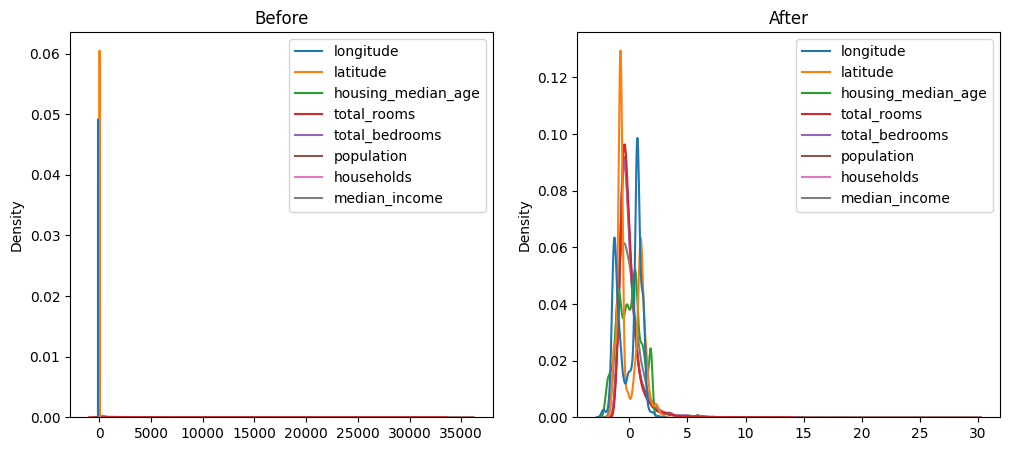

In [24]:
fig ,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
sns.kdeplot(x_train,ax=ax1)
ax1.set_title('Before')
sns.kdeplot(x_train_scaled,ax=ax2)
ax2.set_title("After")
plt.show()

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>, <Axes: >]],
      dtype=object)

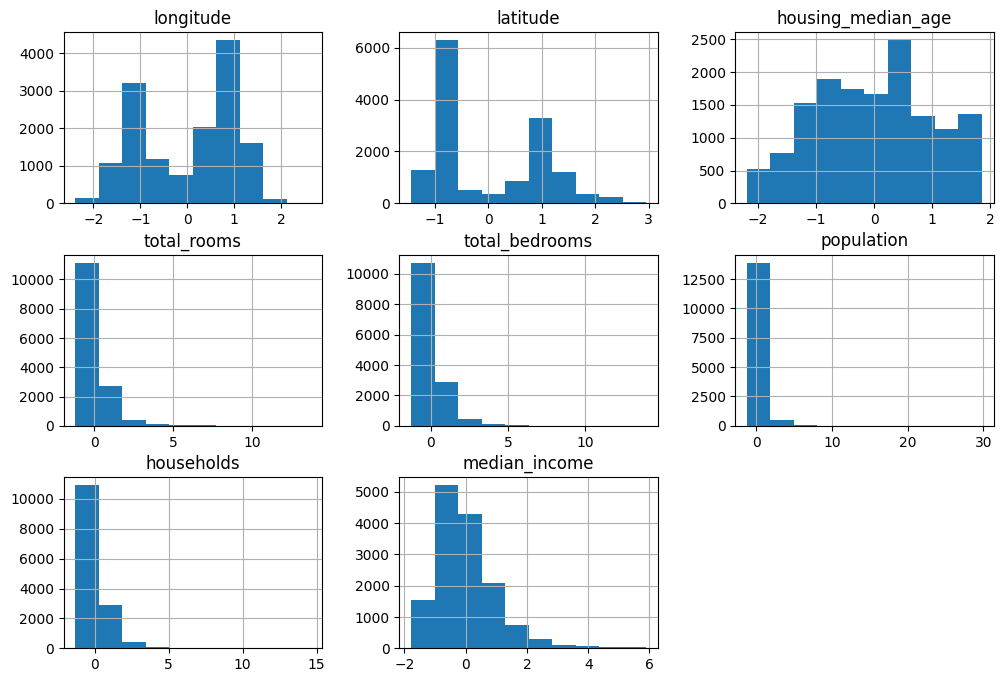

In [23]:
x_train_scaled.hist(figsize=(12,8))

In [25]:
# we can see all the values converged at 0
# it will help various models to run better 